# 🚲 HLBT Baku - Bike: Velosiped İcarəsi Proqnozu

**Məqsəd:** Hava şəraiti, vaxt və digər faktorlara əsasən saatlıq velosiped icarəsini proqnozlaşdırmaq.

**Metrika:** MAE (Mean Absolute Error) — nə qədər aşağı olsa, bir o qədər yaxşıdır.

**Pipeline:**
1. Kitabxanaları yüklə
2. Datanı oxu
3. EDA (Exploratory Data Analysis)
4. Data təmizliyi
5. Feature Engineering
6. Model qur
7. Submission faylı hazırla

## 📦 1. Kitabxanaları yüklə

In [26]:


import pandas as pd          # To work with a table (DataFrame)
import numpy as np           # To perform mathematical operations

# Visualization libraries
import matplotlib.pyplot as plt   # To create plots
import seaborn as sns             # To create more attractive plots

# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor   # Random Forest model
from sklearn.model_selection import cross_val_score  # Cross-validation
from sklearn.metrics import mean_absolute_error      # MAE calculation

# Suppress warnings (to make the code look cleaner)
import warnings
warnings.filterwarnings('ignore')

# Set the figure size for plots
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('✅ All libraries have been successfully loaded!')

✅ All libraries have been successfully loaded!


## 📂 2. Datanı oxu

In [27]:
# Read CSV files into pandas DataFrame
# Files should be in the same directory as this notebook
train = pd.read_csv('train.csv')            # Training data
test  = pd.read_csv('test.csv')             # Test data (count is missing)
sub   = pd.read_csv('sample_submission.csv') # Submission template

print(f'Train size : {train.shape}')   # (number of rows, number of columns)
print(f'Test size  : {test.shape}')
print(f'Submission   : {sub.shape}')

Train size : (8943, 12)
Test size  : (1943, 9)
Submission   : (1943, 2)


In [28]:
# Look at the first 5 rows — understand what the data looks like
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,18,21
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,24,32
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,4,29,33
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,1,13,14
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,0,0


In [29]:
# Each column's data type and number of missing values
# object = text, int64 = integer, float64 = float
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8943 entries, 0 to 8942
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    8943 non-null   str    
 1   season      8943 non-null   int64  
 2   holiday     8943 non-null   int64  
 3   workingday  8943 non-null   int64  
 4   weather     8943 non-null   int64  
 5   temp        8943 non-null   float64
 6   atemp       8943 non-null   float64
 7   humidity    8943 non-null   int64  
 8   windspeed   8943 non-null   float64
 9   casual      8943 non-null   int64  
 10  registered  8943 non-null   int64  
 11  count       8943 non-null   int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 838.5 KB


In [ ]:
# Statistical overview: min, max, mean, standard deviation
train.describe().round(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00,8943.00
mean,2.25,0.03,0.68,1.41,20.35,23.80,61.11,13.00,34.32,142.02,176.33
std,1.05,0.16,0.46,0.64,8.07,8.79,19.60,8.28,48.45,139.10,169.19
min,1.00,0.00,0.00,1.00,0.82,0.76,0.00,0.00,-3.00,-6.00,-7.00
25%,1.00,0.00,0.00,1.00,13.94,16.66,46.00,7.00,3.00,32.00,38.00
50%,2.00,0.00,1.00,1.00,20.50,24.24,61.00,13.00,15.00,108.00,131.00
75%,3.00,0.00,1.00,2.00,27.06,31.06,77.00,19.00,47.00,204.00,263.00
max,4.00,1.00,1.00,4.00,41.00,45.46,100.00,57.00,366.00,792.00,891.00


## 🔍 3. EDA — Datanı kəşf et

In [30]:
# Empty value check
# isnull() — is each cell null? Returns True/False
# sum() — count the True values
print('Null values:')
print(train.isnull().sum())

Null values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [31]:
# Negative count values ​​— these are data errors
neg_mask = train['count'] < 0
print(f'Negative count values: {neg_mask.sum()}')
print(f'Smallest value : {train["count"].min()}')

# Show rows with negative count values
train[neg_mask].head()

Negative count values: 87
Smallest value : -7


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,2,-3,-1
30,2011-01-02 07:00:00,1,0,0,2,16.40,20.455,76,12.9980,-2,0,-2
49,2011-01-03 04:00:00,1,0,1,1,6.56,6.820,47,26.0027,0,-1,-1
93,2011-01-05 01:00:00,1,0,1,1,6.56,9.850,74,6.0032,0,-1,-1
119,2011-01-06 05:00:00,1,0,1,2,5.74,9.090,69,6.0032,-1,0,-1


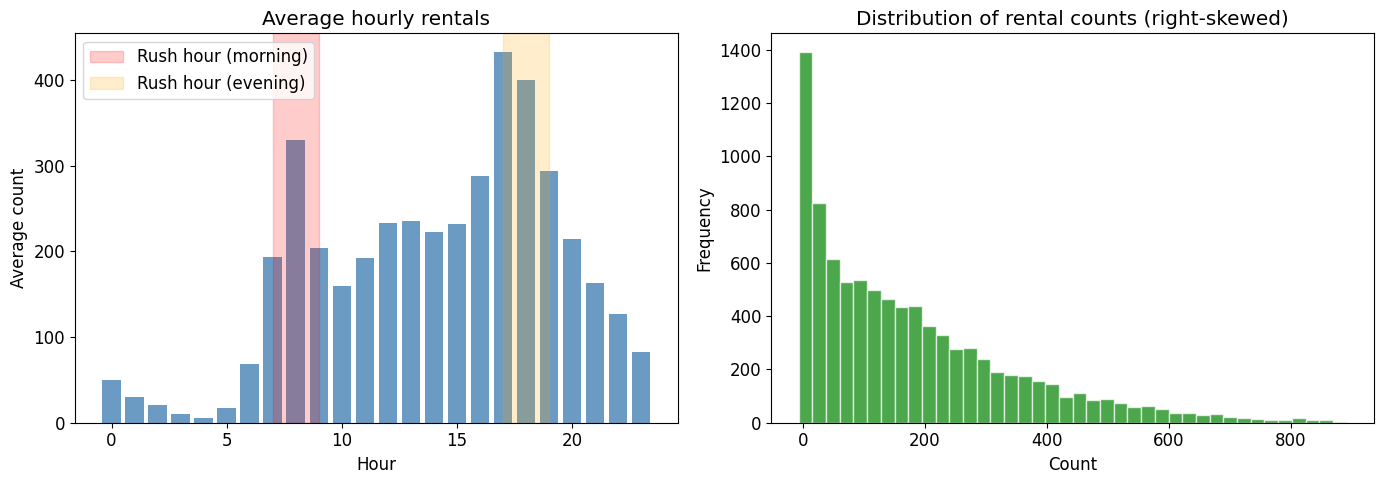

In [32]:
# convert datetime column to date format (for EDA for now)
train['datetime'] = pd.to_datetime(train['datetime'])

# Average hourly rentals
by_hour = train.groupby(train['datetime'].dt.hour)['count'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Hourly rental
axes[0].bar(by_hour.index, by_hour.values, color='steelblue', alpha=0.8)
axes[0].set_title('Average hourly rentals')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average count')
axes[0].axvspan(7, 9, alpha=0.2, color='red', label='Rush hour (morning)')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Rush hour (evening)')
axes[0].legend()

# Right: Count distribution
axes[1].hist(train['count'], bins=40, color='green', alpha=0.7, edgecolor='white')
axes[1].set_title('Distribution of rental counts (right-skewed)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

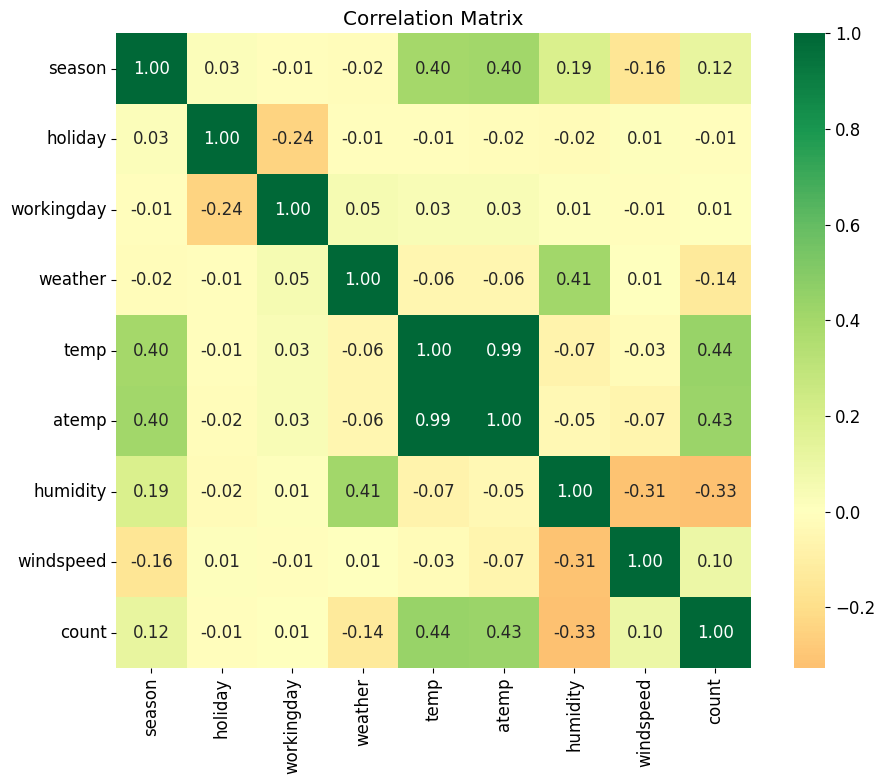

Correlation with Count (from strongest to weakest):
temp          0.436232
atemp         0.432546
season        0.121471
windspeed     0.100845
workingday    0.007313
holiday      -0.009842
weather      -0.137454
humidity     -0.326328
Name: count, dtype: float64


In [33]:
# Correlation matrix — which feature is most closely related to count?
# Correlation: +1 = perfect positive, -1 = perfect negative, 0 = no relationship

num_cols = ['season','holiday','workingday','weather','temp',
            'atemp','humidity','windspeed','count']

corr = train[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,      # Show values
    fmt='.2f',       # 2 decimal digits
    cmap='RdYlGn',   # Red (negative) → Green (positive)
    center=0,        # 0 in the center
    square=True
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlation with Count (from strongest to weakest):')
print(corr['count'].drop('count').sort_values(ascending=False))

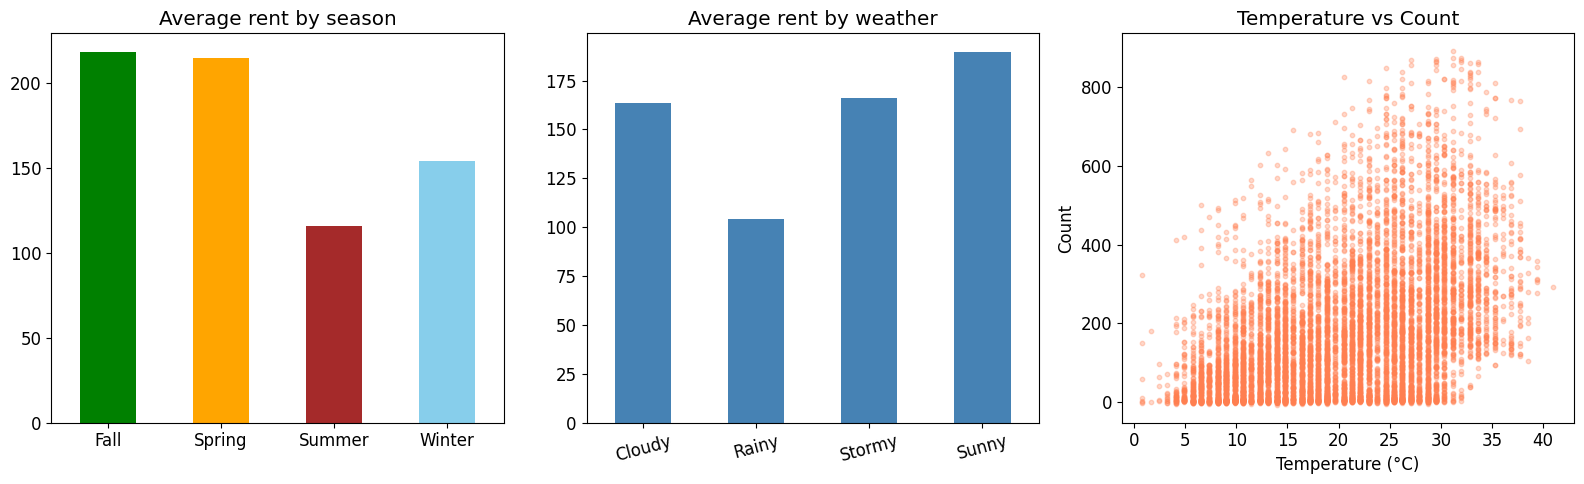

In [34]:
# Visual analysis by season, weather, day of the week
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Season
season_map = {1: 'Summer', 2: 'Spring', 3: 'Fall', 4: 'Winter'}
train['season_name'] = train['season'].map(season_map)
train.groupby('season_name')['count'].mean().plot(kind='bar', ax=axes[0],
    color=['green','orange','brown','skyblue'], rot=0)
axes[0].set_title('Average rent by season')
axes[0].set_xlabel('')

# Weather
weather_map = {1: 'Sunny', 2: 'Cloudy', 3: 'Rainy', 4: 'Stormy'}
train['weather_name'] = train['weather'].map(weather_map)
train.groupby('weather_name')['count'].mean().plot(kind='bar', ax=axes[1],
    color='steelblue', rot=15)
axes[1].set_title('Average rent by weather')
axes[1].set_xlabel('')

# Temp vs Count scatter
axes[2].scatter(train['temp'], train['count'], alpha=0.3, s=10, color='coral')
axes[2].set_title('Temperature vs Count')
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 🧹 4. Data Cleaning

In [35]:
# Remove negative count values ​​— these are data errors
before = len(train)

train = train[train['count'] >= 0].copy()
# .copy() — creates a new copy to avoid changing the original data

after = len(train)
print(f'Before removal: {before} rows')
print(f'After removal: {after} rows')
print(f'Removed: {before - after} rows')

Before removal: 8943 rows
After removal: 8856 rows
Removed: 87 rows


## ⚙️ 5. Feature Engineering — Create new columns

**Feature Engineering** — means creating new, more useful columns from existing data.
For example, extracting `hour` from `datetime` helps the model learn the time pattern.

In [39]:
def add_features(df):
    """
    It adds the same features for both datasets (train and test).
    Advantage of writing a function: we don't write the code twice, the risk of errors is reduced.
    """
    df = df.copy()  # To preserve the original

    # convert datetime column to pandas date format
    df['datetime'] = pd.to_datetime(df['datetime'])

    # Extract new columns from datetime
    df['hour']    = df['datetime'].dt.hour       # 0-23: day's hour
    df['month']   = df['datetime'].dt.month      # 1-12: year's month
    df['weekday'] = df['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['year']    = df['datetime'].dt.year       # 2011 or 2012

    # Rush hour: morning (7-9) and evening (17-19) peak hours
    # .isin() — is the value in the list? Returns True/False
    # .astype(int) — converts True→1, False→0
    df['rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

    # Night hours: usually very low occupancy
    df['night'] = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

    # Working day + Rush hour combination
    # On a working day during rush hour → high rental
    # On a weekend during the same hours → low rental
    df['workingday_rush'] = df['workingday'] * df['rush_hour']

    return df


# Apply to both datasets
train = add_features(train)
test  = add_features(test)

print('New columns added!')
print('Train columns:', list(train.columns))

New columns added!
Train columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'season_name', 'weather_name', 'hour', 'month', 'weekday', 'year', 'rush_hour', 'night', 'workingday_rush', 'log_count']


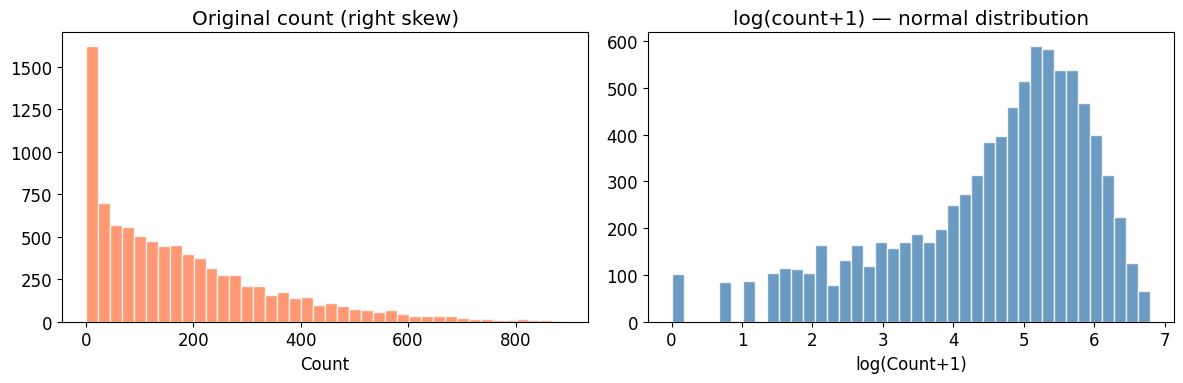

In [40]:
# Log Transform — convert count to a logarithmic scale
#
# Why is it needed?
# - count is right-skewed (many small values, few large values)
# - Log transform helps to normalize the distribution
# - MAE metric performs better with log-scaled data
#
# np.log1p(x) = log(x+1)  →  We add +1 to maintain the value of 0
# (log(0) = -inf since log(0) is undefined)

train['log_count'] = np.log1p(train['count'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['count'], bins=40, color='coral', alpha=0.8, edgecolor='white')
axes[0].set_title('Original count (right skew)')
axes[0].set_xlabel('Count')

axes[1].hist(train['log_count'], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('log(count+1) — normal distribution')
axes[1].set_xlabel('log(Count+1)')

plt.tight_layout()
plt.show()

## 🤖 6. Build Model

In [42]:
# Select the columns the model will use.
# 'casual', 'registered', 'count', 'log_count' — these are TARGET, not features!
# 'datetime', 'season_name', 'weather_name' — unnecessary for the model

features = [
    'season', 'holiday', 'workingday', 'weather',  # Categorical
    'temp', 'atemp', 'humidity', 'windspeed',       # Numerical
    'hour', 'month', 'weekday', 'year',             # Time-based (new)
    'rush_hour', 'night', 'workingday_rush'         # Derived (new)
]

# X = features (input), y = target (output)
X      = train[features]
y      = train['log_count']   # Log-u öyrənir, sonra geri çeviririk
X_test = test[features]

print(f'X shape    : {X.shape}')
print(f'y shape    : {y.shape}')
print(f'X_test shape: {X_test.shape}')

X shape    : (8856, 15)
y shape    : (8856,)
X_test shape: (1943, 15)


In [45]:
# Cross-Validation
#
# Why is it necessary?
# - If we train the model on the entire dataset, how do we evaluate its performance?
# - CV splits the data into 5 parts and uses each part once for testing
# - We get 5 different scores → average them = reliable estimate
#
# cv=5 → 5-fold cross validation
# n_jobs=-1 → use all CPU cores (faster)

rf = RandomForestRegressor(
    n_estimators=200,   # 200 decision trees
    random_state=42,    # Result will be the same each time
    n_jobs=-1           # Use all CPU cores
)

print('Cross-validation is starting... (may take 1-2 minutes)')

# scoring='neg_mean_absolute_error' — sklearn returns a negative value
# We multiply by -1 to make it positive.
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores.mean()

print(f'\n5 CV scores   : {(-cv_scores).round(4)}')
print(f'Average MAE : {cv_mae:.4f} (log scale)')
print(f'\nThis means that the model is wrong by ~{np.expm1(cv_mae):.1f} units on average.')

Cross-validation is starting... (may take 1-2 minutes)

5 CV scores   : [0.6645 0.2792 0.3124 0.5403 0.2861]
Average MAE : 0.4165 (log scale)

This means that the model is wrong by ~0.5 units on average.


In [46]:
# Train the final model using the full data
# CV only was needed for scoring
# Now we train on the entire training data to make it stronger

print('Final model is being trained...')
rf.fit(X, y)
print('✅ Model is ready!')

Final model is being trained...
✅ Model is ready!


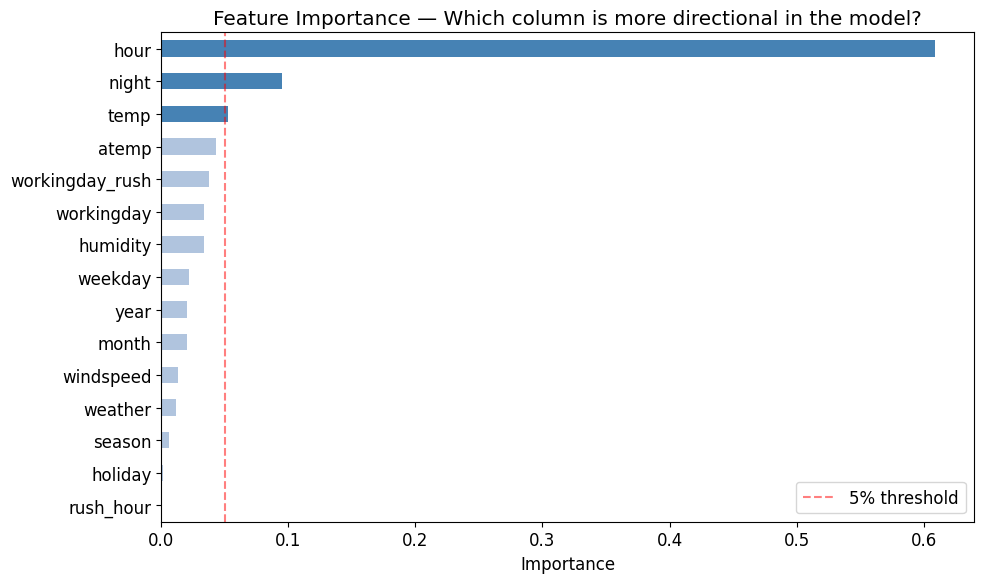


Most Important 5 Features:
hour               0.6091
night              0.0951
temp               0.0524
atemp              0.0433
workingday_rush    0.0374
dtype: float64


In [47]:
# Feature Importance — Which column is more directional in the model?
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['steelblue' if v > 0.05 else 'lightsteelblue' for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — Which column is more directional in the model?')
plt.xlabel('Importance')
plt.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='5% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print('\nMost Important 5 Features:')
print(importances.sort_values(ascending=False).head().round(4))

## 📤 7. Make a prediction and prepare a submission file

In [48]:
# Prediction for test data
preds_log = rf.predict(X_test)

# Reverse log scale: expm1(x) = e^x - 1
# This is the exact opposite of log1p()
preds = np.expm1(preds_log)

# Convert to integer (rental count cannot be a fraction)
preds = preds.round().astype(int)

# Negative predictions to 0 (fix illogical values)
preds = np.maximum(preds, 0)

print(f'Prediction statistics:')
print(f'  Minimum : {preds.min()}')
print(f'  Maximum: {preds.max()}')
print(f'  Mean: {preds.mean():.1f}')
print(f'  Number of rows: {len(preds)}')

Prediction statistics:
  Minimum : 1
  Maximum: 832
  Mean: 212.4
  Number of rows: 1943


In [49]:
# Create a submission file
# Kaggle format: datetime_id, count
sub['count'] = preds

# Save the file
sub.to_csv('submission.csv', index=False)
# index=False → write sequence number (0,1,2...) to file

print('✅ submission.csv is ready!')
print(f'Use this file to upload to Kaggle.')
print()
print('First 5 rows:')
sub.head()

✅ submission.csv is ready!
Use this file to upload to Kaggle.

First 5 rows:


,datetime_id,count
0,1344988800,49
1,1344992400,20
2,1344996000,6
3,1344999600,5
4,1345003200,8


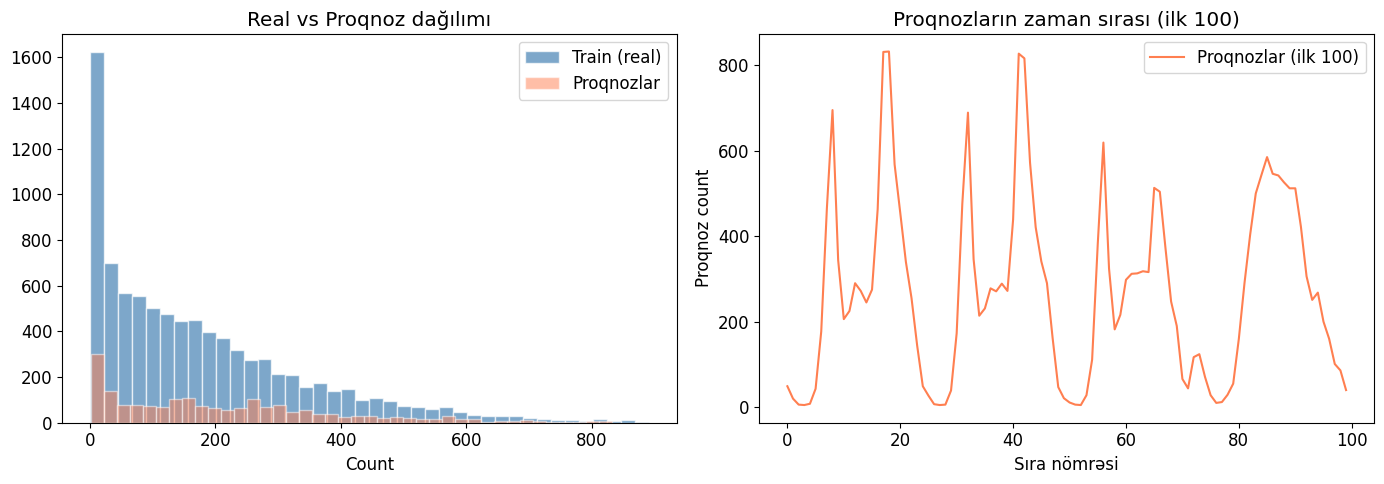

Əgər iki histoqram oxşar formadadırsa — model yaxşı işləyir!


In [25]:
# Proqnozların vizual yoxlaması
# Real train dağılımı ilə proqnoz dağılımını müqayisə et
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['count'], bins=40, color='steelblue', alpha=0.7,
             edgecolor='white', label='Train (real)')
axes[0].hist(preds, bins=40, color='coral', alpha=0.5,
             edgecolor='white', label='Proqnozlar')
axes[0].set_title('Real vs Proqnoz dağılımı')
axes[0].set_xlabel('Count')
axes[0].legend()

axes[1].plot(preds[:100], color='coral', linewidth=1.5, label='Proqnozlar (ilk 100)')
axes[1].set_title('Proqnozların zaman sırası (ilk 100)')
axes[1].set_xlabel('Sıra nömrəsi')
axes[1].set_ylabel('Proqnoz count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Əgər iki histoqram oxşar formadadırsa — model yaxşı işləyir!')

## 🏁 Xülasə

| Addım | Nə etdik |
|---|---|
| 1 | Kitabxanaları yüklədik |
| 2 | train.csv, test.csv oxuduq |
| 3 | EDA: saatlar, mövsüm, korrelyasiya |
| 4 | 87 mənfi count-u sildik |
| 5 | hour, month, weekday, rush_hour, night əlavə etdik |
| 6 | log1p(count) ilə öyrətdik, Random Forest (200 ağac, CV=5) |
| 7 | submission.csv hazırladıq |

**Skoru yaxşılaşdırmaq üçün növbəti addımlar:**
- LightGBM modeli ilə dəyiş
- Optuna ilə hyperparameter tuning
- `casual` və `registered` ayrı-ayrı proqnozlaşdır